# 03 · Normal Distribution and Z-Score

The bell curve is the most famous shape in statistics. Many tests we will use later (z-test, t-test, confidence intervals) are built on it, so it is worth understanding properly.

**What you will learn here**

1. The normal (Gaussian) distribution and its formula
2. The 68-95-99.7 rule, checked on real heights
3. The z-score: how many standard deviations away a value is
4. The standard normal distribution
5. Standardisation vs normalisation (min-max scaling)
6. Finding areas (probabilities) under the curve, the job of the "z-table"
7. Finding outliers with z-scores

## The dataset: Galton's family heights

| | |
|---|---|
| **Name** | GaltonFamilies |
| **Source** | [Rdatasets mirror](https://vincentarelbundock.github.io/Rdatasets/csv/HistData/GaltonFamilies.csv) of the R package `HistData`. Collected by Francis Galton in London in 1886 |
| **Licence** | Historical data, public domain. The `HistData` package is GPL |
| **Rows** | 934 adult children from 205 families |

A copy is saved in `data/galton_heights.csv`.

| Column | Meaning |
|---|---|
| `family` | Family ID |
| `father`, `mother` | Height of the father and mother (inches) |
| `midparentHeight` | Average of the parents' heights, with the mother's height scaled up by 1.08 |
| `children` | Number of children in the family |
| `gender` | Gender of the child |
| `childHeight` | Height of the adult child (inches) |

Heights are in inches, so I convert them to centimetres (1 inch = 2.54 cm) because that is easier to imagine for most readers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

In [2]:
galton = pd.read_csv("../data/galton_heights.csv")
galton["height_cm"] = galton["childHeight"] * 2.54
galton[["family", "father", "mother", "gender", "childHeight", "height_cm"]].head()

,family,father,mother,gender,childHeight,height_cm
0,001,78.5,67.0,male,73.2,185.928
1,001,78.5,67.0,female,69.2,175.768
2,001,78.5,67.0,female,69.0,175.260
3,001,78.5,67.0,female,69.0,175.260
4,002,75.5,66.5,male,73.5,186.690


In [3]:
galton.groupby("gender")["height_cm"].agg(["count", "mean", "median", "std", "min", "max"]).round(1)

,count,mean,median,std,min,max
gender,,,,,,
female,453,162.8,162.6,6.0,142.2,179.1
male,481,175.9,175.8,6.7,152.4,200.7


Men are about 13 cm taller on average, so mixing both genders would give a curve with two humps. For the rest of the notebook we mostly use the **481 men** as one clean group.

In [4]:
men = galton.loc[galton["gender"] == "male", "height_cm"]
women = galton.loc[galton["gender"] == "female", "height_cm"]

---
## 1. The normal (Gaussian) distribution

> **Theory.** A variable is **normally distributed** when its histogram looks like a symmetric bell:

- most values are near the middle
- values get rarer the further you go from the middle
- the left side is a mirror image of the right side
- the mean, median and mode are all at the centre

**Why do we need it?** Many real measurements are close to normal: heights, measurement errors, exam scores of a big group, blood pressure. And, as we will see in notebook 08 (central limit theorem), **averages** of almost any data become normal. That is why most classic tests assume a normal shape.

**Formula** (the probability density function)

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

| Symbol | Meaning |
|---|---|
| $\mu$ | the mean, where the peak is |
| $\sigma$ | the standard deviation, how wide the bell is |
| $e$, $\pi$ | fixed maths constants (2.718... and 3.14159...) |

You don't need to memorise this. The important message is: **a normal curve is fully described by just two numbers, μ and σ.** We write it as $N(\mu, \sigma)$.

Read more: [Normal distribution (Wikipedia)](https://en.wikipedia.org/wiki/Normal_distribution) · the data comes from Galton's study of [regression toward the mean](https://en.wikipedia.org/wiki/Regression_toward_the_mean)

**Small example.** For $\mu = 0$ and $\sigma = 1$, the height of the curve at $x = 0$ is

$$f(0) = \frac{1}{1 \cdot \sqrt{2 \cdot 3.14159}} \cdot e^{0} = \frac{1}{2.5066} = 0.399$$

and at $x = 1$:

$$f(1) = 0.399 \cdot e^{-0.5} = 0.399 \times 0.6065 = 0.242$$

In [5]:
def normal_pdf(x, mu, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

print("By hand formula: f(0) =", round(normal_pdf(0, 0, 1), 3), " f(1) =", round(normal_pdf(1, 0, 1), 3))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
print("scipy:           f(0) =", round(stats.norm.pdf(0, 0, 1), 3), " f(1) =", round(stats.norm.pdf(1, 0, 1), 3))

By hand formula: f(0) = 0.399  f(1) = 0.242
scipy:           f(0) = 0.399  f(1) = 0.242


> **Check:** Matches the manual numbers.

### How μ and σ change the curve

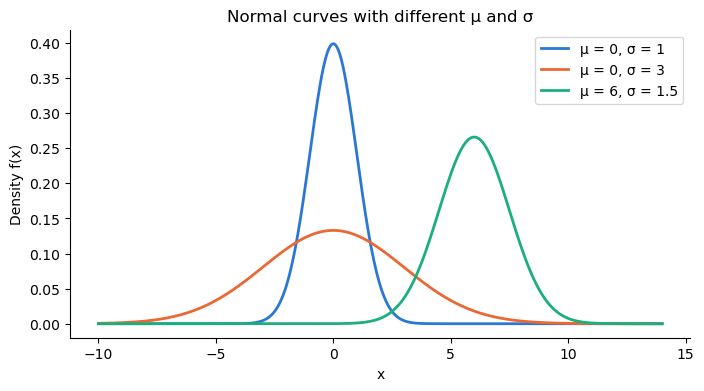

In [6]:
x = np.linspace(-10, 14, 400)

fig, ax = plt.subplots()
ax.plot(x, normal_pdf(x, 0, 1), color=BLUE, linewidth=2, label="μ = 0, σ = 1")
ax.plot(x, normal_pdf(x, 0, 3), color=ORANGE, linewidth=2, label="μ = 0, σ = 3")
ax.plot(x, normal_pdf(x, 6, 1.5), color=GREEN, linewidth=2, label="μ = 6, σ = 1.5")
ax.set_title("Normal curves with different μ and σ")
ax.set_xlabel("x")
ax.set_ylabel("Density f(x)")
ax.legend()
plt.show()

Changing **μ** slides the curve left or right. Changing **σ** makes it narrow and tall (small σ) or wide and flat (big σ). The area under every curve is always 1.

### Are real heights normal?

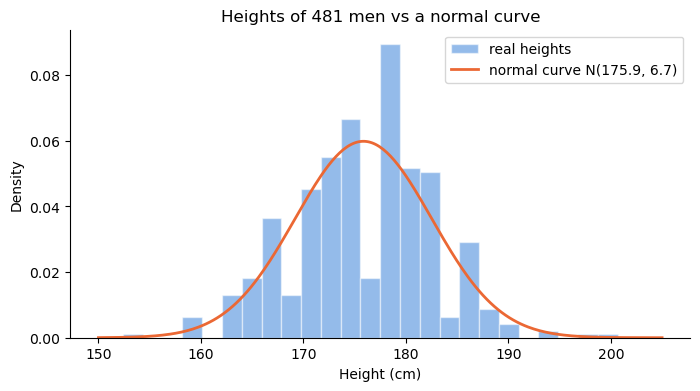

In [7]:
mu, sigma = men.mean(), men.std()

fig, ax = plt.subplots()
ax.hist(men, bins=25, density=True, color=BLUE, alpha=0.5, edgecolor="white", label="real heights")
x = np.linspace(150, 205, 300)
ax.plot(x, normal_pdf(x, mu, sigma), color=ORANGE, linewidth=2, label=f"normal curve N({mu:.1f}, {sigma:.1f})")
ax.set_title("Heights of 481 men vs a normal curve")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

The orange curve uses only the mean and standard deviation of the data, and it follows the bars quite well. Heights of adult men are close to normal.

---
## 2. The empirical rule (68-95-99.7)

> **Theory.** For any normal distribution:

| Range | Share of data inside |
|---|---|
| μ ± 1σ | about **68%** |
| μ ± 2σ | about **95%** |
| μ ± 3σ | about **99.7%** |

So a value more than 3 standard deviations from the mean is very rare (about 3 in 1000). That is the basis of the z-score outlier rule later.

**Check on the men's heights.** μ = 175.9 cm and σ = 6.7 cm, so the rule predicts:

| Range | Heights | Expected share |
|---|---|---|
| μ ± 1σ | 169.2 to 182.5 cm | 68% |
| μ ± 2σ | 162.5 to 189.2 cm | 95% |
| μ ± 3σ | 155.9 to 195.8 cm | 99.7% |

In [8]:
for k, expected in [(1, 68.27), (2, 95.45), (3, 99.73)]:
    low, high = mu - k * sigma, mu + k * sigma
    inside = ((men >= low) & (men <= high)).mean() * 100
    print(f"within {k} sd ({low:.1f} to {high:.1f} cm): real = {inside:.1f}%   normal rule = {expected}%")

within 1 sd (169.2 to 182.5 cm): real = 66.1%   normal rule = 68.27%
within 2 sd (162.5 to 189.2 cm): real = 96.9%   normal rule = 95.45%
within 3 sd (155.9 to 195.8 cm): real = 99.4%   normal rule = 99.73%


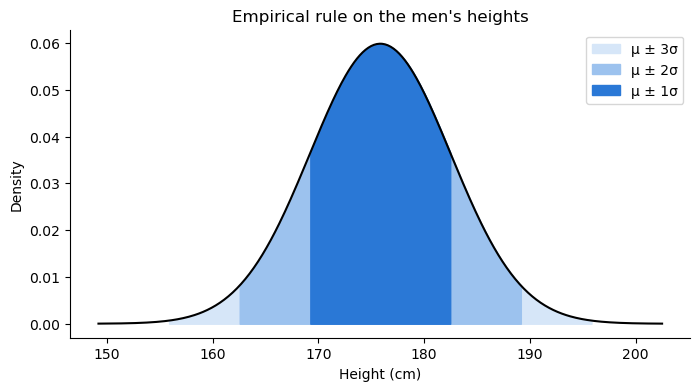

In [9]:
fig, ax = plt.subplots()
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
ax.plot(x, normal_pdf(x, mu, sigma), color="black", linewidth=1.5)
for k, colour in [(3, "#d6e6f8"), (2, "#9cc2ee"), (1, BLUE)]:
    part = (x >= mu - k * sigma) & (x <= mu + k * sigma)
    ax.fill_between(x[part], normal_pdf(x[part], mu, sigma), color=colour, label=f"μ ± {k}σ")
ax.set_title("Empirical rule on the men's heights")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

The real numbers (66%, 97%, 99.4%) are close to the rule. Real data is never perfectly normal, but "close" is often good enough.

---
## 3. Z-score

> **Theory.** The z-score tells us **how many standard deviations a value is away from the mean**.

- z = 0 → exactly at the mean
- z = +2 → 2 standard deviations above the mean
- z = −1.5 → 1.5 standard deviations below the mean

**Why do we need it?** It lets us compare values that live on different scales. Is a 185 cm man "taller" than a 172 cm woman? Not in centimetres, but compared to their own group? The z-score answers that.

**Formula**

$$z = \frac{x - \mu}{\sigma}$$

| Symbol | Meaning |
|---|---|
| $x$ | the value |
| $\mu$ | mean of the group |
| $\sigma$ | standard deviation of the group |

**Small example.** Data with mean 4 and standard deviation 1.

**Manual calculation**

- x = 4.75 → z = (4.75 − 4) / 1 = **0.75** (0.75 sd to the right)
- x = 3.75 → z = (3.75 − 4) / 1 = **−0.25** (0.25 sd to the left)

In [10]:
def z_score(x, mean, sd):
    return (x - mean) / sd

print(z_score(4.75, 4, 1))
print(z_score(3.75, 4, 1))

0.75
-0.25


### A cricket example

In which final did the team do *relatively* better?

| Year | Series average | Series sd | Final score |
|---|---|---|---|
| 2020 | 260 | 12 | 245 |
| 2021 | 250 | 10 | 240 |

By hand: z(2020) = (245 − 260) / 12 = **−1.25**, z(2021) = (240 − 250) / 10 = **−1.00**

Both finals were below average, but 2021 was closer to its own average, so 2021 was relatively better, even though 245 > 240.

In [11]:
print("2020:", z_score(245, 260, 12))
print("2021:", z_score(240, 250, 10))

2020: -1.25
2021: -1.0


### Z-scores on real heights

Who is "taller for their group": a man of 185 cm or a woman of 172 cm?

In [12]:
z_man = z_score(185, men.mean(), men.std())
z_woman = z_score(172, women.mean(), women.std())

print(f"Man   185 cm: z = {z_man:.2f}")
print(f"Woman 172 cm: z = {z_woman:.2f}")

Man   185 cm: z = 1.37
Woman 172 cm: z = 1.53


The man is 9 cm taller in absolute terms, but the woman is further above her own group's average (z ≈ 1.5 vs 1.4). Relative to their groups, she is slightly taller.

---
## 4. Standard normal distribution

> **Theory.** If we turn **every** value into its z-score, the new data always has:

- mean = 0
- standard deviation = 1

A normal distribution with μ = 0 and σ = 1 is called the **standard normal distribution**, written $N(0, 1)$. Every normal curve can be converted into this one, which is why one single table (the z-table) is enough for all normal problems.

**Small example:** 1, 2, 3, 4, 5

**Manual calculation**

- mean = 15 / 5 = 3
- population sd = √[((−2)² + (−1)² + 0² + 1² + 2²) / 5] = √(10/5) = √2 = 1.414
- z-scores: (1−3)/1.414 = **−1.41**, (2−3)/1.414 = **−0.71**, **0**, **0.71**, **1.41**

The new values have mean 0 and sd 1.

In [13]:
values = np.array([1, 2, 3, 4, 5])
z_values = (values - values.mean()) / values.std()   # np.std divides by n here (population)

print("z-scores:", z_values.round(2))
print("new mean:", z_values.mean().round(2), " new sd:", z_values.std().round(2))

z-scores: [-1.41 -0.71  0.    0.71  1.41]
new mean: 0.0  new sd: 1.0


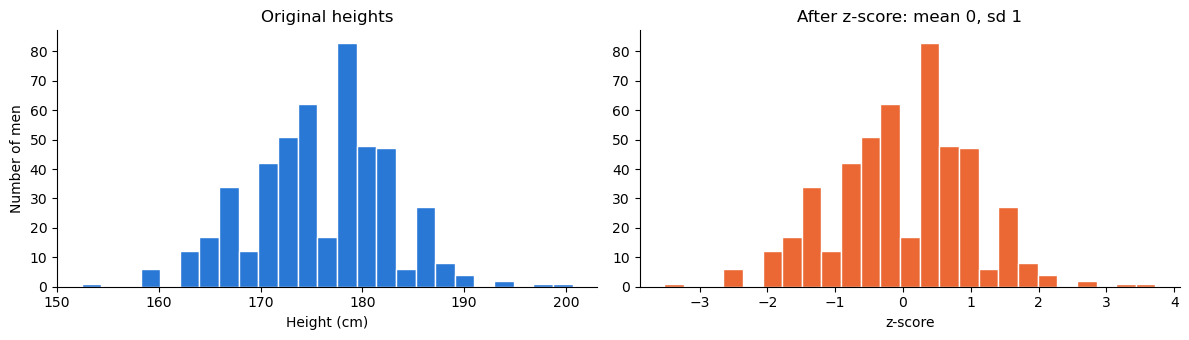

mean of z: 0.0   sd of z: 1.0


In [14]:
men_z = (men - men.mean()) / men.std()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(men, bins=25, color=BLUE, edgecolor="white")
axes[0].set_title("Original heights")
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Number of men")
axes[1].hist(men_z, bins=25, color=ORANGE, edgecolor="white")
axes[1].set_title("After z-score: mean 0, sd 1")
axes[1].set_xlabel("z-score")
plt.tight_layout()
plt.show()

print("mean of z:", abs(round(men_z.mean(), 3)), "  sd of z:", round(men_z.std(), 3))

The shape is exactly the same. Only the numbers on the x-axis changed.

---
## 5. Standardisation vs normalisation

Both are used a lot in machine learning, when features have very different units (age in years, salary in thousands, weight in kg). Many algorithms get confused when one feature is in the thousands and another is between 0 and 1.

| | Standardisation (z-score) | Normalisation (min-max scaling) |
|---|---|---|
| Formula | $z = \dfrac{x - \mu}{\sigma}$ | $x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ |
| Result | mean 0, sd 1, no fixed range | always between 0 and 1 |
| Typical use | linear models, PCA, data with outliers | images (pixels 0-255 → 0-1), neural networks |

**Small example (min-max):** 2, 5, 6, 8, 1 → min = 1, max = 8, so max − min = 7

**Manual calculation**

| x | (x − 1) / 7 |
|---|---|
| 2 | 1/7 = 0.143 |
| 5 | 4/7 = 0.571 |
| 6 | 5/7 = 0.714 |
| 8 | 7/7 = 1.000 |
| 1 | 0/7 = 0.000 |

In [15]:
x = np.array([2, 5, 6, 8, 1])
x_minmax = (x - x.min()) / (x.max() - x.min())
print(x_minmax.round(3))

[0.143 0.571 0.714 1.    0.   ]


Now on real columns with different units: the father's height (inches) and the number of children in the family.

In [16]:
features = galton[["father", "children"]]

standardised = (features - features.mean()) / features.std()
normalised = (features - features.min()) / (features.max() - features.min())

comparison = pd.DataFrame({
    "father (in)": features["father"],
    "children": features["children"],
    "father z": standardised["father"],
    "children z": standardised["children"],
    "father 0-1": normalised["father"],
    "children 0-1": normalised["children"],
}).round(2)
comparison.head()

,father (in),children,father z,children z,father 0-1,children 0-1
0,78.5,4,3.76,-0.8,1.00,0.21
1,78.5,4,3.76,-0.8,1.00,0.21
2,78.5,4,3.76,-0.8,1.00,0.21
3,78.5,4,3.76,-0.8,1.00,0.21
4,75.5,4,2.55,-0.8,0.82,0.21


After scaling, both columns are on comparable scales, so neither one dominates just because of its units.

---
## 6. Areas under the curve (the z-table)

> **Theory.** For a continuous variable, a **probability is an area under the density curve**. The total area is 1 (100%).

The **cumulative distribution function (CDF)** gives the area to the **left** of a value: $P(X \le x)$. A printed z-table is just the CDF of the standard normal written in a table. Today we use `scipy.stats.norm.cdf` instead of the paper table, but the idea is identical.

Read more: [Standard normal table (Wikipedia)](https://en.wikipedia.org/wiki/Standard_normal_table)

Three rules cover every case:

| Question | Area |
|---|---|
| Below a | CDF(a) |
| Above a | 1 − CDF(a) |
| Between a and b | CDF(b) − CDF(a) |

### Question 1

Data has μ = 4 and σ = 1. What percentage of values is **above 4.25**?

**By hand**

1. z = (4.25 − 4) / 1 = 0.25
2. z-table at 0.25 → 0.5987 (area to the left)
3. Area above = 1 − 0.5987 = **0.4013 → 40.13%**

In [17]:
z = (4.25 - 4) / 1
area_left = stats.norm.cdf(z)
print("area left of z = 0.25:", round(area_left, 4))
print("area above 4.25      :", round(1 - area_left, 4))

area left of z = 0.25: 0.5987
area above 4.25      : 0.4013


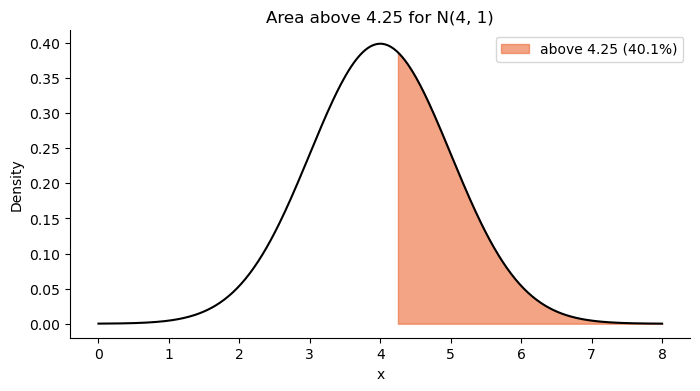

In [18]:
x = np.linspace(0, 8, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x, 4, 1), color="black")
right_side = x >= 4.25
ax.fill_between(x[right_side], stats.norm.pdf(x[right_side], 4, 1), color=ORANGE, alpha=0.6, label="above 4.25 (40.1%)")
ax.set_title("Area above 4.25 for N(4, 1)")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend()
plt.show()

### Question 2: IQ

IQ is designed to have μ = 100 and σ = 15. What percentage of people have an IQ **below 85**?

**By hand:** z = (85 − 100) / 15 = −1 → table → **0.1587 → 15.87%**

### Question 3

What percentage have an IQ **between 100 and 125**?

**By hand:**
- z(125) = (125 − 100) / 15 = 1.67 → CDF = 0.9525
- z(100) = 0 → CDF = 0.5
- between = 0.9525 − 0.5 = **0.4525 → 45.25%**

In [19]:
print("IQ below 85          :", round(stats.norm.cdf(85, loc=100, scale=15) * 100, 2), "%")

between = stats.norm.cdf(125, 100, 15) - stats.norm.cdf(100, 100, 15)
print("IQ between 100 and 125:", round(between * 100, 2), "%")

IQ below 85          : 15.87 %
IQ between 100 and 125: 45.22 %


> **Check:** Both match the manual results (small differences come from rounding z to 1.67 by hand).

### Question 4 on real data

What share of men in the data are **taller than 180 cm**? We can answer two ways: using the normal model, or by just counting.

In [20]:
model_answer = 1 - stats.norm.cdf(180, loc=men.mean(), scale=men.std())
real_answer = (men > 180).mean()

print(f"Normal model says: {model_answer * 100:.1f}%")
print(f"Real count says  : {real_answer * 100:.1f}%")

Normal model says: 26.7%
Real count says  : 28.9%


The model is off by about 2 percentage points. That is the price of describing 481 people with only two numbers. Good enough for a quick estimate, and the model also works for questions where we have no data at all, like "how many men are taller than 2 metres?".

### Going backwards: from area to value

`norm.ppf` (percent point function) does the opposite of `cdf`: you give the area and get the value. A tailor wants to know the height above which only the tallest 5% of men are.

In [21]:
height_top_5 = stats.norm.ppf(0.95, loc=men.mean(), scale=men.std())
print(f"Top 5% of men are taller than {height_top_5:.1f} cm")
print("z for the 95th percentile:", round(stats.norm.ppf(0.95), 3))

Top 5% of men are taller than 186.8 cm
z for the 95th percentile: 1.645


You will see **1.645** and **1.96** again and again in hypothesis tests: 1.645 leaves 5% in one tail, 1.96 leaves 2.5% in each tail (5% in total).

---
## 7. Finding outliers with z-scores

> **Theory.** If the data is roughly normal, only 0.3% of values should be more than 3 standard deviations away from the mean. So a common rule is:

> flag a value as an outlier if $|z| > 3$

It only makes sense for data that is close to normal. For skewed data (like the restaurant bills) the IQR rule from notebook 02 is safer.

In [22]:
def detect_outliers_z(data, threshold=3):
    mean = np.mean(data)
    sd = np.std(data)
    outliers = []
    for value in data:
        z = (value - mean) / sd
        if abs(z) > threshold:
            outliers.append(value)
    return outliers

print("Outliers by z-score:", detect_outliers_z(men))

Outliers by z-score: [198.12, 200.66, 152.4]


In [23]:
# docs: https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html
q1, q3 = men.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_outliers = men[(men < q1 - 1.5 * iqr) | (men > q3 + 1.5 * iqr)]
print("Outliers by IQR    :", sorted(iqr_outliers.round(2).tolist()))

Outliers by IQR    : [152.4, 194.31, 198.12, 200.66]


Both methods agree on the extreme cases (about 152 cm, 198 cm and 201 cm). The IQR rule also flags 194.3 cm, because its fences are a bit tighter. These are real people, not errors, so in a real analysis I would keep them.

---
## Summary

| Concept | Key point |
|---|---|
| Normal distribution | Symmetric bell, fully described by μ and σ |
| Empirical rule | 68% / 95% / 99.7% within 1 / 2 / 3 standard deviations |
| Z-score | $(x - \mu) / \sigma$, distance from the mean in sd units |
| Standard normal | N(0, 1), what you get after z-scoring |
| Standardisation | z-score: mean 0, sd 1 |
| Normalisation | min-max: range 0 to 1 |
| CDF / z-table | area to the left of a value |
| PPF | from area back to value (1.645, 1.96) |
| Z-score outliers | \|z\| > 3, only for roughly normal data |

## What's next

In **04 · Probability** we learn the basic rules of probability (addition, multiplication, conditional probability) and count arrangements with permutations and combinations, using the Titanic passenger list.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), section 4.1 (normal distribution)
- [68-95-99.7 rule, Wikipedia](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule)
- [Standard score (z-score), Wikipedia](https://en.wikipedia.org/wiki/Standard_score) · [Feature scaling, Wikipedia](https://en.wikipedia.org/wiki/Feature_scaling)
- [scipy `norm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html): `pdf`, `cdf` and `ppf` are all methods of this object